# PyTorch

tensor is a special type of data structure

By default, tensors are created on the CPU. We need to explicitly move tensors to the GPU using '.to' method(after checking for GPU availability)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [ ]:
# We can convert a numpy ndarray to a tensor
import numpy as np
a = np.ones(5)
b = torch.from_numpy(a)
print(a)
print(b)

# we move the tensor to the GPU if available
tensor=b.to(device)
print("Device tensor is stored on:",tensor.device)

[1. 1. 1. 1. 1.]
tensor([1., 1., 1., 1., 1.], dtype=torch.float64)
Device tensor is stored on: cuda:0


In [ ]:
# can line up trailing dimensions to make reading easier
x=torch.ones(5,1,4,1)
y=torch.ones(  3,1,1)
print((x+y).size())
#torch.Size([5, 3, 4, 1])

# but not necessary:
x=torch.ones(1)
y=torch.ones(3,1,7)
print((x+y).size())
#torch.Size([3, 1, 7])

x=torch.ones(5,2,4,1)
y=torch.ones(3,1,1)
print((x+y).size())
#RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 1

torch.Size([5, 3, 4, 1])
torch.Size([3, 1, 7])


RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 1

# Gradient descent to optimize a function

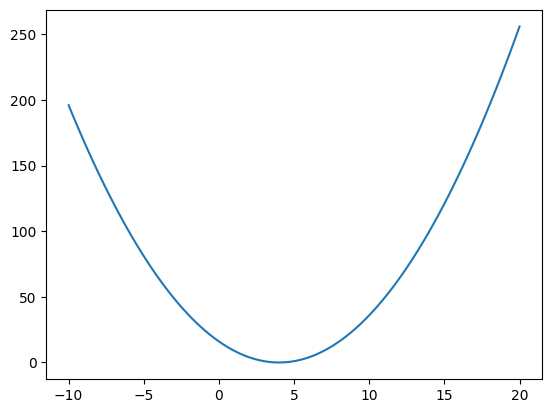

In [ ]:
import torch
x=torch.linspace(-10,20,100)
y=(x-4)**2

plt.figure(dpi=100)
plt.plot(x,y)
plt.show()

For gradient descent:
1.   We need an **initial guess** for our solution
2.   **backward()** will automatically compute the gradients, which can be retrieved using **.grad**



In [ ]:
x=torch.rand(1,requires_grad=True)
print('x=',x,'\n')
print('x_grad=',x.grad,'\n')

y=(x-4)**2
y.backward()
print('x_grad=',x.grad,'\n')

learning_rate=0.1
print('x_grad=',x.grad,'\n')
print('x-x_grad=',x-learning_rate*x.grad,'\n')

with torch.no_grad():
  x-=learning_rate*x.grad
print('x=',x,'\n')

x.requires_grad=True
print('x=',x,'\n')

x= tensor([0.6118], requires_grad=True) 

x_grad= None 

x_grad= tensor([-6.7764]) 

x_grad= tensor([-6.7764]) 

x-x_grad= tensor([1.2894], grad_fn=<SubBackward0>) 

x= tensor([1.2894], requires_grad=True) 

x= tensor([1.2894], requires_grad=True) 



In [ ]:
x=torch.rand(1,requires_grad=True)
print('Initial x=',x,'\n')
x0=x.clone().detach()

max_iter = 100
learning_rate = 0.1
eps = 1e-6

for i1 in range(max_iter):
    y = (x - 4) ** 2
    y.backward()
    with torch.no_grad():
        prev_x = x
        x = x - learning_rate * x.grad
        if torch.norm(prev_x - x) < eps:
            print('break at iter', i1, '\n')
            break
    x.requires_grad = True

print('Soln x:', x, '\n')


Initial x= tensor([0.8208], requires_grad=True) 

break at iter 60 

Soln x: tensor([4.0000]) 



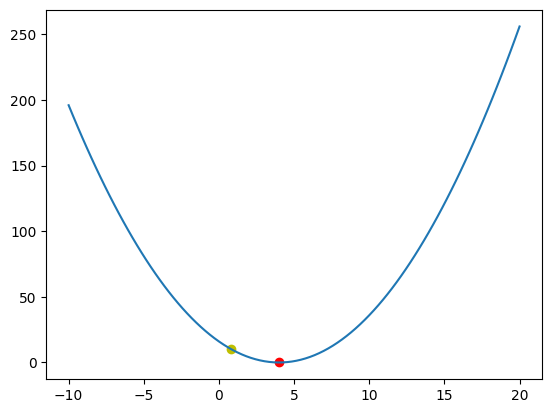

In [ ]:
x1 = torch.linspace(-10,20,100)
y1 = (x1 - 4) ** 2

plt.figure(dpi=100)
plt.plot(x1, y1)
plt.scatter(x0, (x0 - 4) ** 2, c='y')
plt.scatter(x, (x - 4) ** 2, c='r')
plt.show()

Gradient Descent using **torch.optim**

Steps of using an optimezer:
1.   Initialize Optimizer
2.   In the optimization loop:
  *   Explicitly set the gradients to zero
  *   Perform the necessary operations
  *   Compute the gradients
  *   Update the parameters using the computed gradients

In [ ]:
import torch
import torch.optim as optim

x=torch.rand(1,requires_grad=True)
print('Initial x=',x,'\n')
x0=x.clone().detach()

max_iter=100
learning_rate=0.1
eps=1e-6

optimizer=optim.SGD([x],lr=learning_rate)

for i in range(max_iter):
  optimizer.zero_grad() # Explicitly set the gradients to zero
  y=(x-4)**2 # Perform the necessary operations
  y.backward() # Compute the gradients
  prev_x=x.clone().detach()
  optimizer.step() # Update the parameters using the computed gradients
  if torch.norm(prev_x-x)<eps:
    print('break at iter',i,'\n')
    break

print('Soln x=',x,'\n')

Initial x= tensor([0.7482], requires_grad=True) 

break at iter 60 

Soln x= tensor([4.0000], requires_grad=True) 



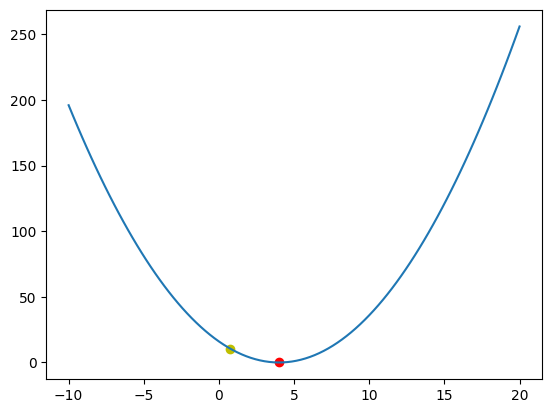

In [ ]:
x1 = torch.linspace(-10,20,100)
y1 = (x1 - 4) ** 2

plt.figure(dpi=100)
plt.plot(x1, y1)
plt.scatter(x0, (x0 - 4) ** 2, c='y')
plt.scatter(x.detach(), (x.detach() - 4) ** 2, c='r')
plt.show()

# Linear Regression

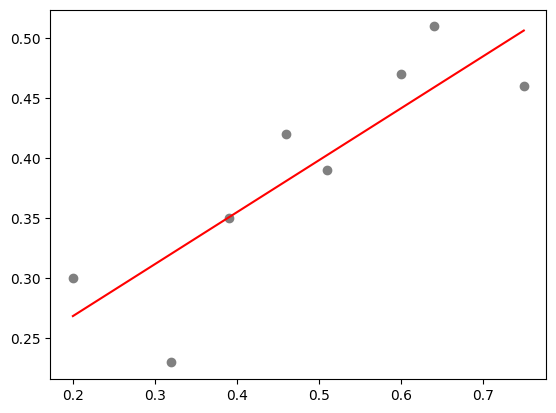

In [ ]:
data = torch.tensor([[0.2,0.3], [0.32,0.23], [0.39,0.35], [0.46, 0.42], [0.51, 0.39], [0.6, 0.47], [0.64, 0.51], [0.75, 0.46]])

x = data[:,0]
y = data[:,1]

w = torch.randn(2, requires_grad=True)
w0 = w.clone().detach()

max_iter = 1000
learning_rate = 1e-2
eps = 1e-6

optimizer = optim.SGD([w], lr=learning_rate)
for i1 in range(max_iter):
    optimizer.zero_grad()  # (b) i. Explicitly set the gradients to zero

    # (b) ii. Perform the necessary operations:
    est_y = w[0] + (w[1] * x)
    loss = ((y - est_y) ** 2).sum()

    loss.backward()  # (b) ii. Compute the gradients

    prev_w = w.clone()

    optimizer.step()  # (b) iii. Update the parameters using the computed gradients

    if torch.norm(prev_w - w) < eps:
      print('break at iter', i1)
      break

w_soln = w.clone().detach()

plt.figure()
plt.scatter(x, y, marker='o', c='gray')
plt.plot(x, w_soln[0] + (w_soln[1] * x), c='r')
# plt.plot(x, w0[0] + (w0[1] * x), c='y')
plt.show()

# Logistic Regression

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3885087765.py:7: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{y}$')
/tmp/ipython-input-3885087765.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma(\hat{y})$', rotation=0)


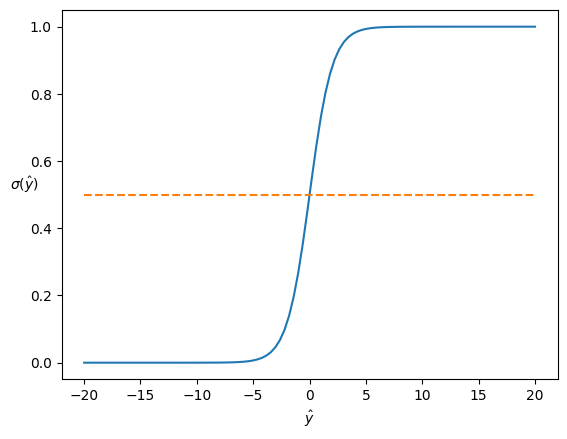

In [ ]:
x=torch.linspace(-20,20,100)
y=1/(1+torch.exp(-x))

plt.figure(dpi=100)
plt.plot(x,y)
plt.plot(x, torch.zeros((100))+0.5, linestyle='--')
plt.xlabel('$\hat{y}$')
plt.ylabel('$\sigma(\hat{y})$', rotation=0)
plt.show()

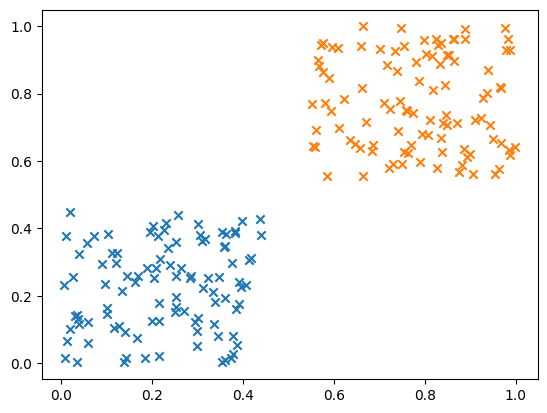

In [ ]:
a1 = torch.rand(size=(100,2)) * (0 - 0.45) + 0.45
a2 = torch.rand(size=(100,2)) * (0.55 - 1) + 1

X = torch.hstack((torch.ones((200,1)), torch.vstack((a1, a2))))
y = torch.hstack(( torch.zeros((100)), torch.ones((100)) ))

plt.scatter(a1[:,0], a1[:,1], marker='x')
plt.scatter(a2[:,0], a2[:,1], marker='x')

plt.show()

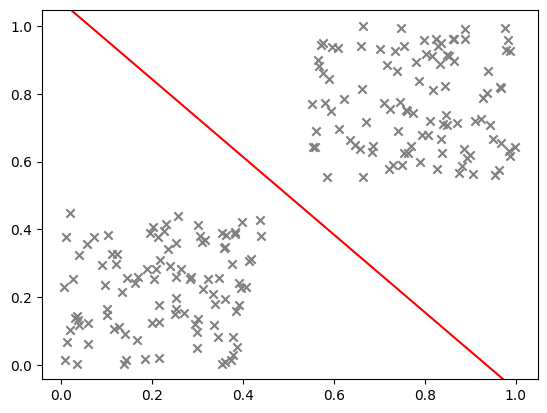

In [ ]:
w = torch.randn(3) * 2 -1
w.requires_grad=True

max_iter = 100
learning_rate = 0.1
eps = 1e-6

# (a) Initialize Optimizer
optimizer = optim.SGD([w], lr=learning_rate)

for i1 in range(max_iter):
    optimizer.zero_grad()  # (b) i. Explicitly set the gradients to zero

    # (b) ii. Perform the necessary operations:
    est_y = torch.matmul(X, w)
    sigmoid = 1 / (1 + torch.exp(-est_y))
    cross_entropy_loss = -(y * torch.log(torch.fmax(sigmoid, torch.tensor([1e-6]))) + (1 - y) * torch.log(torch.fmax(1 - sigmoid, torch.tensor([1e-6])))).sum()

    cross_entropy_loss.backward()  # (b) ii. Compute the gradients

    prev_w = w.clone()

    optimizer.step()  # (b) iii. Update the parameters using the computed gradients

    if torch.norm(prev_w - w) < eps:
      print('break at iter', i1)
      break

w_soln = w.clone().detach()

plt.figure()
plt.scatter(X[:,1], X[:,2], marker='x', c='gray')
extreme_xvals = torch.tensor([X[:,1].min(), X[:,1].max()])
plt.plot(extreme_xvals, (-w_soln[0] - w_soln[1] * extreme_xvals) / w_soln[2], c='r')
plt.ylim(extreme_xvals+torch.tensor([-0.05, 0.05]))
plt.show()

# Integer and Boolean indexing

In [ ]:
v1 = torch.tensor([2,4,6])

print('v1[0] =', v1[0], '\n')
print('v1[1] =', v1[1], '\n')
print('v1[2] =', v1[2], '\n')

print('v1[[0,1,2]] =', v1[[0,1,2]], '\n')

print('v1[[0,0,0]] =', v1[[0,0,0]], '\n')

print('v1[[0,0,0,1,1,1,2,2,2]] =', v1[[0,0,0,1,1,1,2,2,2]], '\n')

print('v1[-1] =', v1[-1], '\n')

print('v1[-2] =', v1[-2], '\n')

print('v1[-3] =', v1[-3], '\n')

print('v1[[-3,-2,-1]] =', v1[[-3,-2,-1]], '\n')

print('v1[[-1,-1,-1]] =', v1[[-1,-1,-1]], '\n')

M1 = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])

print('M1 =\n', M1, '\n')

print('M1[0] =', M1[0], '\n')

print('M1[[0,0,0]] =\n', M1[[0,0,0]], '\n')

print('M1[[0,0,0,1,1,1,2,2,2]] =\n', M1[[0,0,0,1,1,1,2,2,2]], '\n')

v1[0] = tensor(2) 

v1[1] = tensor(4) 

v1[2] = tensor(6) 

v1[[0,1,2]] = tensor([2, 4, 6]) 

v1[[0,0,0]] = tensor([2, 2, 2]) 

v1[[0,0,0,1,1,1,2,2,2]] = tensor([2, 2, 2, 4, 4, 4, 6, 6, 6]) 

v1[-1] = tensor(6) 

v1[-2] = tensor(4) 

v1[-3] = tensor(2) 

v1[[-3,-2,-1]] = tensor([2, 4, 6]) 

v1[[-1,-1,-1]] = tensor([6, 6, 6]) 

M1 =
 tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]) 

M1[0] = tensor([1, 2, 3]) 

M1[[0,0,0]] =
 tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]]) 

M1[[0,0,0,1,1,1,2,2,2]] =
 tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3],
        [4, 5, 6],
        [4, 5, 6],
        [4, 5, 6],
        [7, 8, 9],
        [7, 8, 9],
        [7, 8, 9]]) 



In [ ]:
v1 = torch.tensor([2,4,6])

M1 = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])

print('v1[[True,True,True]] =', v1[[True,True,True]], '\n')

print('v1[[True,False,True]] =', v1[[True,False,True]], '\n')

#print(v1[[True,False]]) # Will produce an error

print('v1[[True,False,False]] =', v1[[True,False,False]], '\n')

print('v1[[False,False,False]] =', v1[[False,False,False]], '\n')

print('v1 > 2 =', v1 > 2)

print('v1[v1 > 2] =', v1[v1 > 2], '\n')

print('v1[v1 < 5] =', v1[v1 < 5], '\n')

print('v1[v1 == 4] =', v1[v1 == 4], '\n')

M1 = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])

print('M1 =\n', M1, '\n')


print('M1[M1 > 3] =', M1[M1 > 3], '\n')

print('M1[M1 < 5] =', M1[M1 < 5], '\n')

print('torch.where(M1 < 5) =\n', torch.where(M1 < 5), '\n')

rows, cols = torch.where(M1 < 5)
for i1 in range(rows.shape[0]):
    print(rows[i1], cols[i1], M1[rows[i1], cols[i1]])

v1[[True,True,True]] = tensor([2, 4, 6]) 

v1[[True,False,True]] = tensor([2, 6]) 

v1[[True,False,False]] = tensor([2]) 

v1[[False,False,False]] = tensor([], dtype=torch.int64) 

v1 > 2 = tensor([False,  True,  True])
v1[v1 > 2] = tensor([4, 6]) 

v1[v1 < 5] = tensor([2, 4]) 

v1[v1 == 4] = tensor([4]) 

M1 =
 tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]) 

M1[M1 > 3] = tensor([4, 5, 6, 7, 8, 9]) 

M1[M1 < 5] = tensor([1, 2, 3, 4]) 

torch.where(M1 < 5) =
 (tensor([0, 0, 0, 1]), tensor([0, 1, 2, 0])) 

tensor(0) tensor(0) tensor(1)
tensor(0) tensor(1) tensor(2)
tensor(0) tensor(2) tensor(3)
tensor(1) tensor(0) tensor(4)


# K-Means Clustering

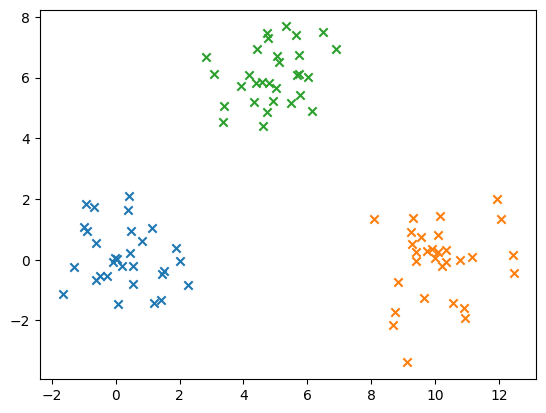

In [ ]:
X1 = torch.randn((30,2))
X2 = torch.randn((30,2)) + torch.tensor([10,0])
X3 = torch.randn((30,2)) + torch.tensor([5,6])

plt.figure(dpi=100)
plt.scatter(X1[:,0], X1[:,1], marker='x')
plt.scatter(X2[:,0], X2[:,1], marker='x')
plt.scatter(X3[:,0], X3[:,1], marker='x')
plt.show()

In [ ]:
X = torch.vstack((X1, X2, X3))
print(X.shape)
print(X[:5,:])

torch.Size([90, 2])
tensor([[-0.0086,  0.0635],
        [-0.2629, -0.5316],
        [ 0.0794, -1.4637],
        [ 1.5145, -0.3686],
        [ 1.1362,  1.0534]])


break at iter 2


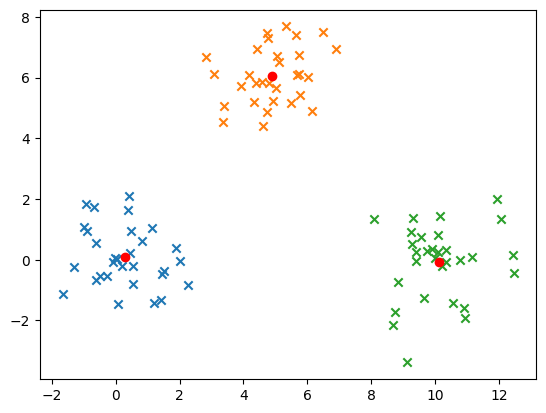

In [ ]:
def kmeans(X, k, max_iter=100, tol=1e-6):
    # Implement k-Means Clustering
    # 1. Initial step: Randomly initialize k cluster centers
    centers = X[torch.randperm(X.shape[0])[0:k]]
    for i2 in range(max_iter):
        # 2. (i) Calculate the distance of all data points to all cluster centers
        dist = torch.cdist(X, centers)
        # 2. (ii) For each data point, which cluster center lies closest to it
        mem = dist.argmin(axis=1)
        # 2. (iii) Recompute our cluster centers, as the mean of the data points that are closest to it
        prev_centers = centers.clone().detach()
        for j in range(k):
          centers[j] = X[mem==j].mean(axis=0)
        if torch.norm(centers - prev_centers) < tol:
          print('break at iter', i2)
          break
    return centers, mem

centers, mem = kmeans(X, k=3)

plt.figure(dpi=100)
for j in range(3):
  plt.scatter(X[mem==j,0], X[mem==j,1], marker='x')
plt.scatter(centers[:,0], centers[:,1], marker='o', c='r')
plt.show()

# Dataset DataLoader

In [ ]:
from google.colab import drive
drive.mount('/gdrive0')

Mounted at /gdrive0


In [ ]:
%matplotlib inline

There we have

1. torch.utils.data.DataLoader
2. torch.utils.data.Dataset





In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 182kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.50MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.0MB/s]


3
4
6
8
9
3
5
9
1


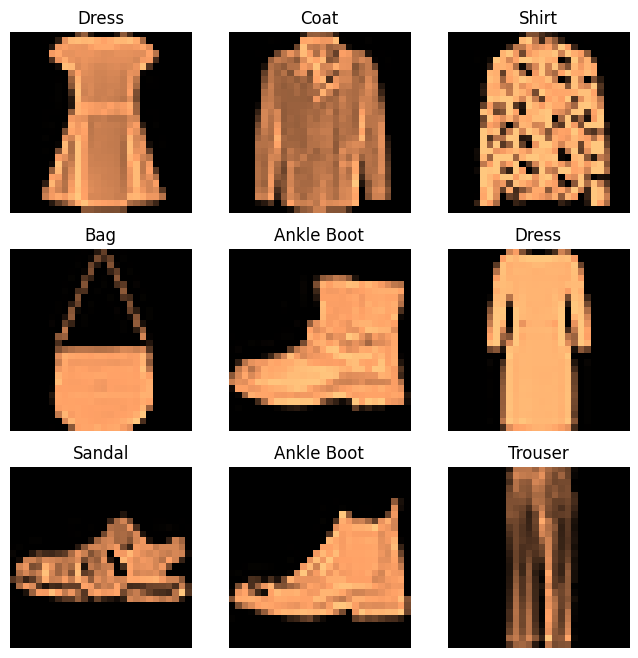

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8,8))
cols, rows = 3,3
for i in range(1, cols*rows+1):
  sample_idx = torch.randint(len(training_data),size=(1,)).item()
  img,label = training_data[sample_idx]
  print(label)
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(),cmap="copper")
# plt.show %as we declare "%matplotlib inline"

# Creating a custom dataset for our files


In [ ]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
  def __init__(self,annotations_file,img_dir,transform=None,target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.img_labels)

  def __getitem__(self,idx):
    img_path = os.path.join(self.img_dir,self.img_labels.iloc[idx,0])
    image = read_image(img_path)
    label = self.img_labels.iloc[idx,1]
    if self.transform:
      image = self.transform(image)
    if self.target_transform:
      label = self.target_transform(image)

# Preaparing your data for training with DataLoaders

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

We can iterate through the DataLoader

# Displaying single image in a batch

Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])


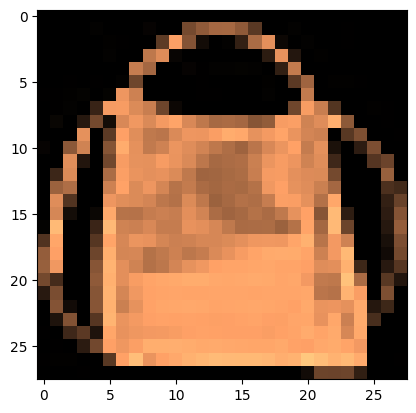

Label: 8


In [ ]:
train_features, train_labels = next(iter(train_dataloader))

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img,cmap="copper")
plt.show()
print(f"Label: {label}")

#displaying images in entire batch

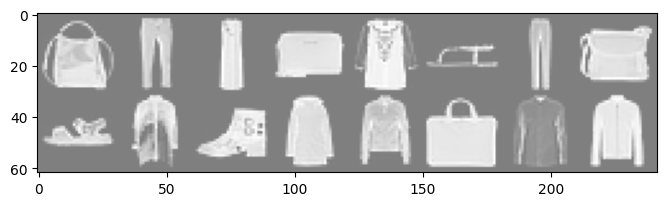

In [ ]:
import numpy as np
import torchvision

def imshow(img):
  img = img/2+0.5
  npimg=img.numpy()
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.show()

figure = plt.figure(figsize=(8,8))
imshow(torchvision.utils.make_grid(train_features))

# accessing all the batches in the entire dataset

Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])
0


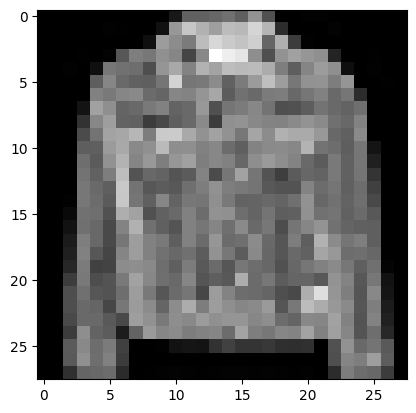

Label: Coat
Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])
1


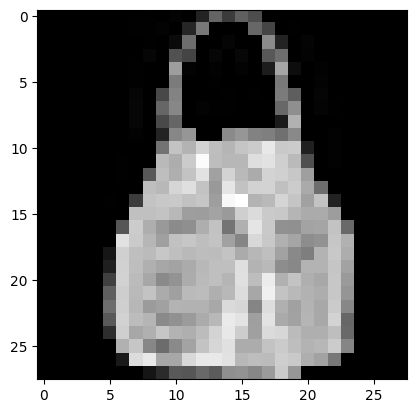

Label: Bag
Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])
2


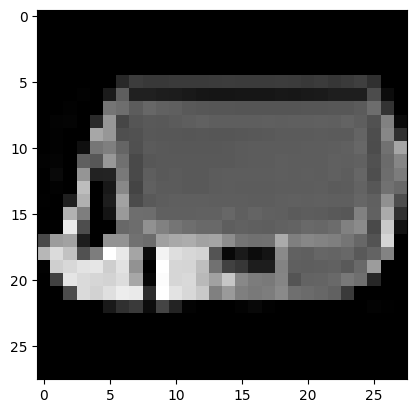

Label: Bag
Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])
3


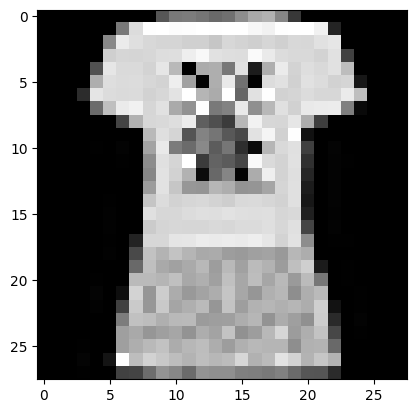

Label: T-Shirt
Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])
4


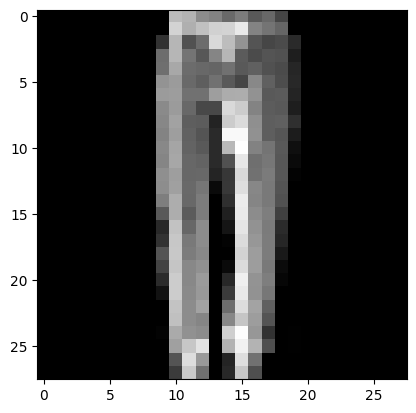

Label: Trouser
Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])
5


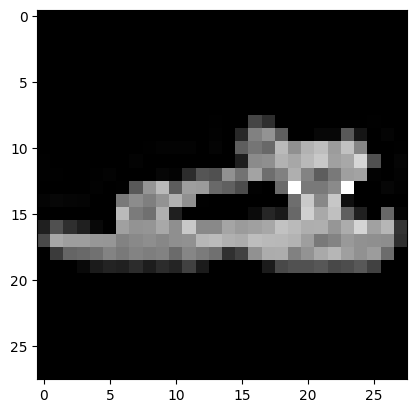

Label: Sandal
Feature batch shape: torch.Size([16, 1, 28, 28])
Labels batch shape: torch.Size([16])
6


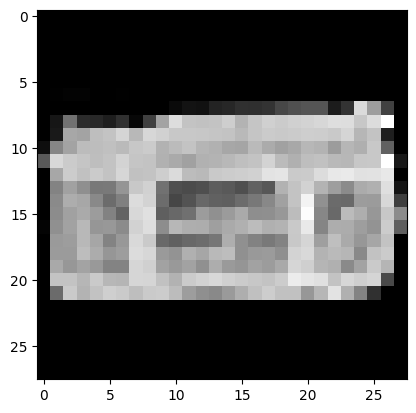

Label: Bag


In [ ]:
from dataclasses import dataclass

for i, data in enumerate(train_dataloader, 0):

    train_features, train_labels = data

    print(f"Feature batch shape: {train_features.size()}")
    print(f"Labels batch shape: {train_labels.size()}")

    img = train_features[0].squeeze()
    label = train_labels[0]
    print(i)
    plt.imshow(img, cmap="gray")
    plt.show()
    print(f"Label: {labels_map[label.item()]}")
    if i>5:
      break

# Loading Audio/Text data in PyTorch

In [ ]:
import torch
import torchaudio

1. Import all necessary libraries for loading our data
2. Access the data in the dataset
3. Loading the data
4. Iterate over the data
5. [Optional] Visualize the data


In [ ]:
torchaudio.datasets.YESNO(
    root="./",
    url="http://www.openslr.org/resources/1/waves_yesno.tar.gz",
    folder_in_archive="waves_yesno",
    download=True
)

100%|██████████| 4.49M/4.49M [00:01<00:00, 3.61MB/s]


In [ ]:
!pip install torchCodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 98.0 MB/s eta 0:00:00


In [ ]:
# A data point in Yesno is a tuple (waveform, sample_rate, labels) where labels
# is a list of integers with 1 for yes and 0 for no.
yesno_data = torchaudio.datasets.YESNO("./",download=True)

# Pick data point number 3 to see an example of the the yesno_data:
n = 3
waveform, sample_rate, labels = yesno_data[n]
print("Waveform: {}\nSample rate: {}\nLabels: {}".format(waveform, sample_rate, labels))

Waveform: tensor([[ 3.0518e-05,  6.1035e-05,  3.0518e-05,  ..., -1.8311e-04,
          4.2725e-04,  6.7139e-04]])
Sample rate: 8000
Labels: [0, 0, 1, 0, 0, 0, 1, 0]


In [ ]:
n = 20
waveform, sample_rate, labels = yesno_data[n]
print("Waveform: {}\nSample rate: {}\nLabels: {}".format(waveform, sample_rate, labels))

Waveform: tensor([[ 3.0518e-05,  6.1035e-05,  3.0518e-05,  ..., -1.4343e-03,
         -1.3428e-03, -1.3428e-03]])
Sample rate: 8000
Labels: [0, 1, 0, 0, 1, 0, 1, 1]


In [ ]:
data_loader = torch.utils.data.DataLoader(yesno_data,
                                          batch_size=1,
                                          shuffle=True)

In [ ]:
for data in data_loader:
  print("Data: ", data)
  print("Waveform: {}\nSample rate: {}\nLabels: {}".format(data[0], data[1], data[2]))
  break

Data:  [tensor([[[ 3.0518e-05,  6.1035e-05,  3.0518e-05,  ..., -1.7090e-03,
          -4.7302e-03, -3.7537e-03]]]), tensor([8000]), [tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([1])]]
Waveform: tensor([[[ 3.0518e-05,  6.1035e-05,  3.0518e-05,  ..., -1.7090e-03,
          -4.7302e-03, -3.7537e-03]]])
Sample rate: tensor([8000])
Labels: [tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([1])]


[[ 3.0517578e-05  6.1035156e-05  3.0517578e-05 ... -1.7089844e-03
  -4.7302246e-03 -3.7536621e-03]]


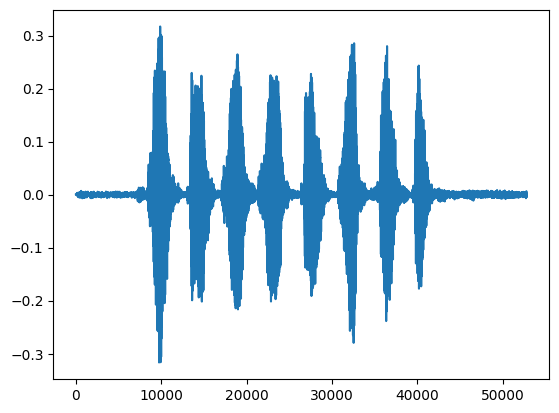

In [ ]:
print(data[0][0].numpy())

plt.figure()
plt.plot(waveform.t().numpy())

# Data transforms

In [ ]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(), # converts a PIL image or NumPy ndarray into a FloatTensor, and scales the image's pixel intensity values in the range [0.,1.]
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)) # Lambda transformation apply any user-defined lambda functions.
)

tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])


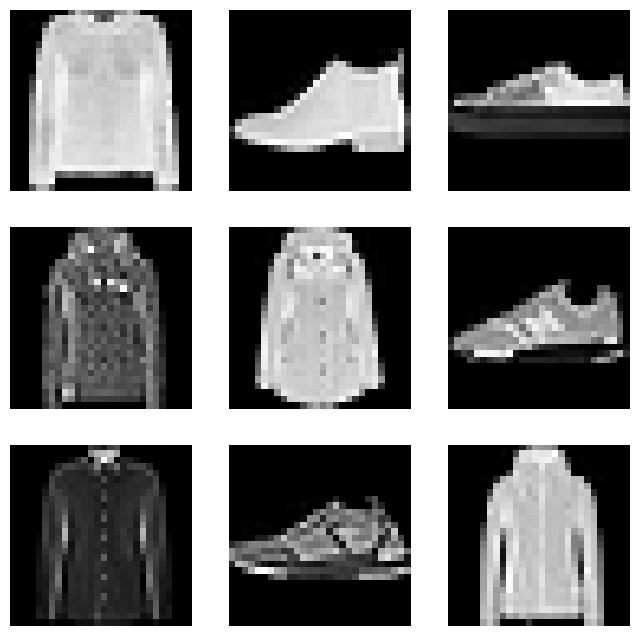

In [ ]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(ds), size=(1,)).item()
    img, label = ds[sample_idx]
    print(label)
    figure.add_subplot(rows, cols, i)
    # plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Various transformations on images

In [ ]:
# For color images
from torchvision import transforms

data_transform = transforms.Compose([
    # transforms.RandomResizedCrop(28),
    # transforms.CenterCrop(18),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485],
                         std=[0.229])
])

In [ ]:
ds_1 = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=data_transform,
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])
tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])
tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])
tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])


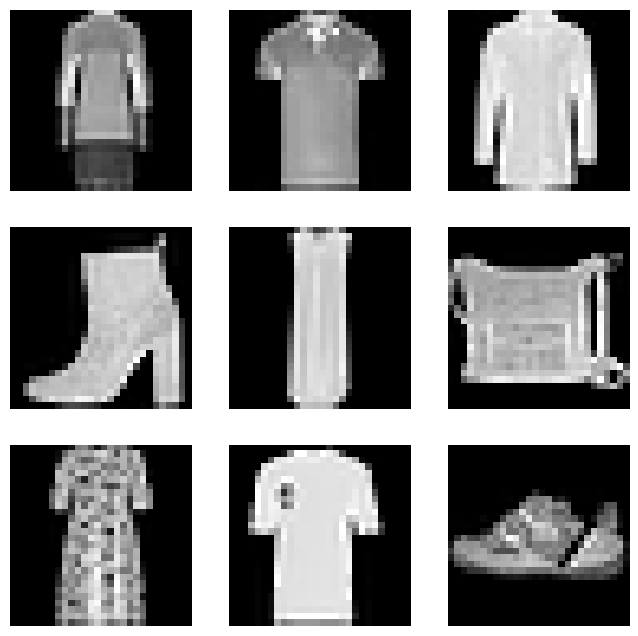

In [ ]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(ds), size=(1,)).item()
    img, label = ds_1[sample_idx]
    print(label)
    figure.add_subplot(rows, cols, i)
    # plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Training a image classifier

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

batch_size=16

trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data',
                                        train=False,
                                        download=True,
                                        transform=transform)
testloader = torch.utils.data.DataLoader(testset,
                                          batch_size=batch_size,
                                          shuffle=False,
                                          num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:14<00:00, 11.7MB/s]


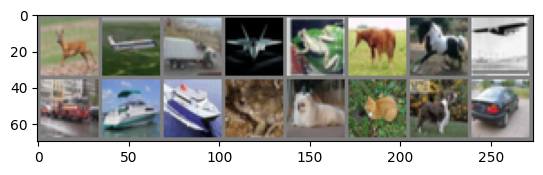

deer  plane truck plane frog  horse horse plane truck ship  ship  frog  dog   cat   dog   car  


In [ ]:
def imshow(img):
  img = img/2+0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
use_gpu = torch.cuda.is_available()
print(use_gpu)

True


In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
net = net.cuda()

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.cuda(), labels.cuda()

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.179
[2,  2000] loss: 1.595
Finished Training


# Saving trained model

In [ ]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

Test the network on the test data

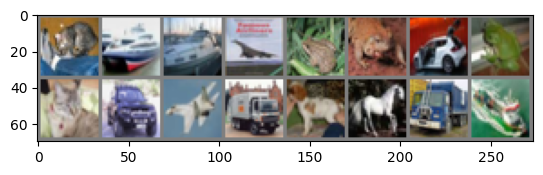

GroundTruth:  cat   ship  ship  plane frog  frog  car   frog  cat   car   plane truck dog   horse truck ship 


In [ ]:
dataiter = iter(testloader) #An iterator allows you to traverse through elements of a collection one item at a time,
                            #which is more memory-efficient than loading the entire collection at once, especially for large datasets.
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(16)))

In [ ]:
net=Net()
net.load_state_dict(torch.load(PATH))
net=net.cuda()
images, labels = images.cuda(),labels.cuda()

In [ ]:
output=net(images)

In [ ]:
_, predicted = torch.max(outputs, 1)

print(predicted)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(16)))

tensor([1, 7, 3, 7, 5, 2, 6, 9, 2, 7, 8, 3, 8, 7, 8, 3], device='cuda:0')
Predicted:  car   horse cat   horse dog   bird  frog  truck bird  horse ship  cat   ship  horse ship  cat  


Now lets look at how the network performs on the whole dataset

In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.cuda(), labels.cuda()
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 48 %


What are the classes that performed well and the classes that did not perform well..

In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.cuda(), labels.cuda()
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 43.8 %
Accuracy for class: car   is 54.5 %
Accuracy for class: bird  is 35.5 %
Accuracy for class: cat   is 46.5 %
Accuracy for class: deer  is 13.9 %
Accuracy for class: dog   is 32.9 %
Accuracy for class: frog  is 66.2 %
Accuracy for class: horse is 58.5 %
Accuracy for class: ship  is 70.7 %
Accuracy for class: truck is 59.9 %
